
Final chip positions:
c1: (x=1, y=0, w=2, h=4)
c2: (x=3, y=1, w=2, h=5)
c3: (x=6, y=0, w=1, h=3)
c4: (x=0, y=4, w=2, h=5)
c5: (x=6, y=3, w=2, h=4)
c6: (x=5, y=2, w=1, h=4)
c7: (x=2, y=5, w=2, h=5)
c8: (x=5, y=6, w=1, h=3)

Final Conflict Score: 26


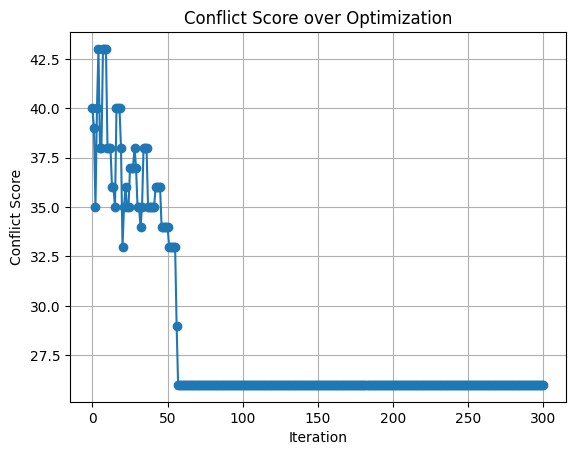

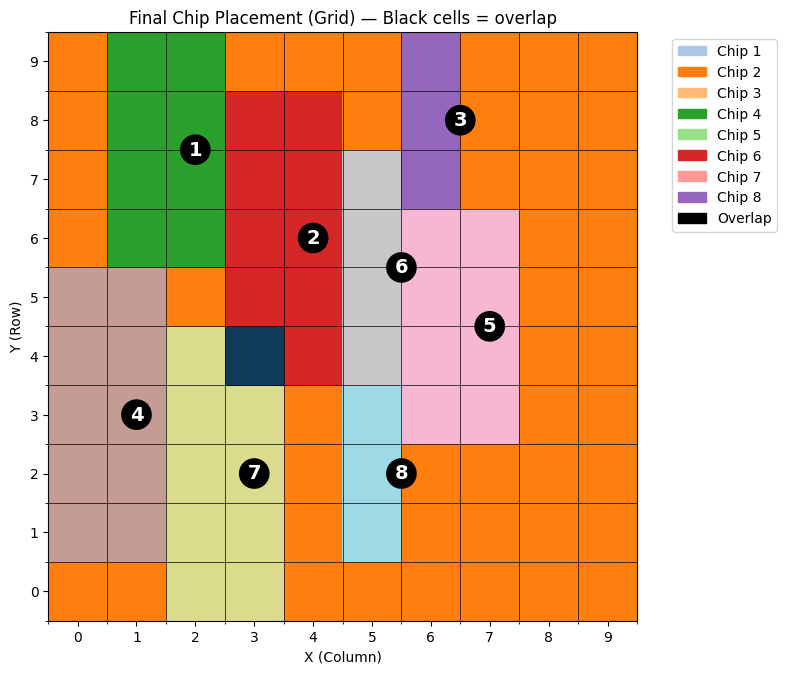

In [5]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Assignment instance (fixed)
W, H = 10, 10
chips = {
    1: [2, 4, 0, 0],  # w, h, y, x
    2: [2, 5, 1, 1],
    3: [1, 3, 0, 1],
    4: [2, 5, 4, 2],
    5: [2, 4, 3, 3],
    6: [1, 4, 2, 2],
    7: [2, 5, 5, 0],
    8: [1, 3, 6, 4],
}
connections = [
    (1,2), (2,6), (2,3), (3,5), (4,5),
    (5,6), (1,6), (7,4), (7,2), (8,5)
]

def overlap_blocks(c1, c2, chipset):
    w1, h1, y1, x1 = chipset[c1]
    w2, h2, y2, x2 = chipset[c2]
    x_overlap = max(0, min(x1+w1, x2+w2) - max(x1, x2))
    y_overlap = max(0, min(y1+h1, y2+h2) - max(y1, y2))
    return x_overlap * y_overlap

def wiring_cost(c1, c2, chipset):
    w1, h1, y1, x1 = chipset[c1]
    w2, h2, y2, x2 = chipset[c2]
    horiz_gap = max(0, x2 - (x1 + w1), x1 - (x2 + w2))
    vert_gap = abs(y1 - y2)
    return horiz_gap + vert_gap

def conflict_score(chipset):
    score = 0
    for c1, c2 in connections:
        score += wiring_cost(c1, c2, chipset)
    for i in range(1, len(chipset)+1):
        for j in range(i+1, len(chipset)+1):
            score += overlap_blocks(i, j, chipset)
    return score

def optimize_chips(max_iter=200, restarts=3):
    best_overall_score = float('inf')
    best_overall_config = None
    best_scores = []
    for r in range(restarts):
        current_chips = {cid: vals[:] for cid, vals in chips.items()}
        current_score = conflict_score(current_chips)
        best_score = current_score
        scores = [current_score]
        T = 10.0
        cooling = 0.95
        for it in range(max_iter):
            cid = random.choice(list(current_chips.keys()))
            old_x = current_chips[cid][3]
            dx = random.choice([-1, 1])
            new_x = max(0, min(W - current_chips[cid][0], old_x + dx))
            current_chips[cid][3] = new_x
            new_score = conflict_score(current_chips)
            if new_score < current_score:
                current_score = new_score
            else:
                prob = math.exp(-(new_score - current_score) / max(T, 1e-6))
                if random.random() < prob:
                    current_score = new_score
                else:
                    current_chips[cid][3] = old_x
            if current_score < best_score:
                best_score = current_score
            scores.append(current_score)
            T *= cooling
        if best_score < best_overall_score:
            best_overall_score = best_score
            best_overall_config = {cid: vals[:] for cid, vals in current_chips.items()}
            best_scores = scores
    for cid in chips:
        chips[cid] = best_overall_config[cid]
    return best_scores, best_overall_score

# Run optimization (more restarts and iterations for stronger optimization)
scores, final_score = optimize_chips(max_iter=300, restarts=10)

print("\nFinal chip positions:")
for cid, (w,h,y,x) in chips.items():
    print(f"c{cid}: (x={x}, y={y}, w={w}, h={h})")
print("\nFinal Conflict Score:", final_score)

# Plot Conflict Score over iterations
plt.plot(scores, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Conflict Score")
plt.title("Conflict Score over Optimization")
plt.grid(True)
plt.show()


# Enhanced Visualization of Final Chip Placement
def draw_chip_grid(chips, W, H):
    grid = np.zeros((H, W), dtype=int)
    chip_colors = plt.cm.tab20(np.linspace(0, 1, len(chips)+1))
    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw chips and mark overlaps as -1
    for cid, (w, h, y, x) in chips.items():
        for yy in range(y, min(y+h, H)):
            for xx in range(x, min(x+w, W)):
                if grid[yy, xx] == 0:
                    grid[yy, xx] = cid
                else:
                    grid[yy, xx] = -1  # overlap

    # Show grid with custom colormap: overlaps are black
    cmap = plt.cm.tab20
    norm = plt.Normalize(vmin=-1, vmax=len(chips))
    im = ax.imshow(grid[::-1], cmap=cmap, norm=norm, origin="lower")

    # Highlight overlaps with semi-transparent gray overlay
    overlap_mask = (grid == -1)[::-1]
    ax.imshow(np.where(overlap_mask, 1, np.nan), cmap='gray', alpha=0.5, origin="lower")

    # Draw gridlines
    ax.set_xticks(np.arange(-0.5, W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, H, 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=0.5)

    # Draw chip IDs in chip centers
    for cid, (w, h, y, x) in chips.items():
        cx = x + w/2
        cy = y + h/2
        ax.text(cx, H - cy - 0.5, str(cid), color="white", fontsize=14, fontweight='bold',
                ha='center', va='center', bbox=dict(facecolor='black', edgecolor='none', boxstyle='circle,pad=0.3'))

    ax.set_title("Final Chip Placement (Grid) — Black cells = overlap")
    ax.set_xlabel("X (Column)")
    ax.set_ylabel("Y (Row)")
    ax.set_xticks(range(W))
    ax.set_yticks(range(H))

    # Legend for chips and overlap
    patches = [mpatches.Patch(color=cmap(i/20), label=f'Chip {i}') for i in chips.keys()]
    patches.append(mpatches.Patch(color='black', label='Overlap'))
    ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.25,1))

    plt.tight_layout()
    plt.show()

draw_chip_grid(chips, W, H)
